# Conjunction Example

Analysis of one conjunction.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cdflib
import csv
import datetime as dt
import pymap3d as pm
from scipy.signal import welch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from gnssparser import parse
from gnssutils import power_detrend, phase_detrend, calc_ipp

# Update rcParams for larger fonts  
# mpl.rcParams.update({  
#     "font.size": 12,           # Base font size  
#     "axes.titlesize": 16,      # Title font size  
#     "axes.labelsize": 14,      # Axis label font size  
#     "xtick.labelsize": 12,     # X-tick font size  
#     "ytick.labelsize": 12,     # Y-tick font size  
#     "legend.fontsize": 12,     # Legend font size  
#     "font.family": "sans-serif",  # Use sans-serif fonts (cleaner for plots)  
#     "font.sans-serif": ["Arial", "DejaVu Sans"]  # Fallback fonts  
# })  


To set up this notebook for a particular conjunction:

1. Select a conjunction from the `conjunction_list.iynb` notebook and enter the relevant information below.
2. Download the appropriate Swarm file
3. Download the appropriate CHAIN file


This code deals with three different ranges of time.
- GNSS data are available in blocks of 1 hour.
- The `time_lims` variable specifies the range of Swarm data that are retrieved.  This is usually on the order of 10 minutes, but can be adjusted.
- The `zoom_lims` variable specifies the very narrow time window directly around the conjunction that should be used for conjunction spectral analysis.

Note that both `time_lims` and `zoom_lims` (as defined below) are centered around the conjunction time.

We currently don't have a good method for dealing with conjunctions very close to the hour boundary where the GNSS data files split.

In [2]:
receiver_name = 'res'
conjtime = dt.datetime(2024,5,10,14,24,0)
insitu = 'Swarm A'
prn = 'G22'

time_lims = [conjtime-dt.timedelta(minutes=5), conjtime+dt.timedelta(minutes=5)]
time_lims = [np.datetime64(t.isoformat()) for t in time_lims]
zoom_lims = [conjtime-dt.timedelta(seconds=30), conjtime+dt.timedelta(seconds=30)]
zoom_lims = [np.datetime64(t.isoformat()) for t in zoom_lims]


swarm_filename = 'data/swarm/SW_EXTD_EFIA_LP_FP_20240510T001849_20240510T192423_0202.cdf'
gnss_filename = 'data/gnss/240510_140000.nvd.gz'

## Swarm Data
Read in Swarm data and make a simple plot of density.

In [3]:
v = cdflib.CDF(swarm_filename)

swarm_time = cdflib.epochs.CDFepoch.to_datetime(v.varget('Timestamp'))

# Find indices for time range
stidx = np.argmin(np.abs(time_lims[0]-swarm_time))
etidx = np.argmin(np.abs(time_lims[1]-swarm_time))
# print(stidx, etidx)

swarm_time = swarm_time[stidx:etidx+1]
#swarm_utime = swarm_time.astype('datetime64[s]').astype(int)
#swarm_utime = swarm_utime[stidx:etidx]

swarm_lat = v.varget('Latitude', startrec=stidx, endrec=etidx)
swarm_lon = v.varget('Longitude', startrec=stidx, endrec=etidx)
swarm_alt = v.varget('Height', startrec=stidx, endrec=etidx)*1000.
dens = v.varget('Density', startrec=stidx, endrec=etidx)

# # Quality flags
# qf = v.varget('Quality_flags', startrec=stidx, endrec=etidx)
# cf = v.varget('Calibration_flags', startrec=stidx, endrec=etidx)

# # Read velocities
# Vixh = v.varget('Vixh', startrec=stidx, endrec=etidx)
# Vixv = v.varget('Vixv', startrec=stidx, endrec=etidx)
# Viy = v.varget('Viy', startrec=stidx, endrec=etidx)
# Viz = v.varget('Viz', startrec=stidx, endrec=etidx)

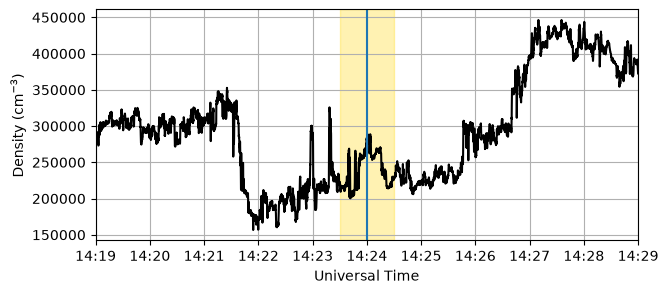

In [13]:
fig = plt.figure(figsize=(7,3))
ax = fig.add_subplot(111)
ax.plot(swarm_time, dens, color='black')
ax.set_xlim(time_lims)
ax.axvspan(xmin=zoom_lims[0], xmax=zoom_lims[1], color='gold', alpha=0.3)
ax.axvline(conjtime)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.grid()
ax.set_xlabel('Universal Time')
ax.set_ylabel('Density (cm$^{-3}$)')
# ax.set_ylim([0,7.e5])
plt.savefig('swarm_exmp.png')

## GNSS Data

Determine site coordinates from `CHAINsites.txt`.

In [14]:
with open('CHAINsites.txt', 'r') as cf:
    chain_data = csv.reader(cf)
    for row in chain_data:
        if row[1] == receiver_name:
            receiver_site = [float(row[2]), float(row[3]), 0.]

print(receiver_site)

[74.746627, 264.997469, 0.0]


Function to convert GPS time to numpy UTC time stamp.  This was originally part of the `gnssutils` package, but it needs some modification, so moving it local for now.

In [15]:
def gps2utc(wnc, tow):
    # THIS FUNCTION DOES NOT HANDLE LEAP SECONDS CORRECTLY
    # There is a way to do this with spacepy, but it is extremely slow and will sometimes crash because it runs out of memory
    # Until this is solved, output will be off by ~18 seconds
    gps_tstmp = (np.array(wnc)*7*24*60*60*1000+np.array(tow)).astype(int)
    gps_epoch = np.datetime64('1980-01-06').astype('datetime64[ms]').astype(int)
    time = (gps_epoch + gps_tstmp).astype('datetime64[ms]')
    time = time - np.timedelta64(18,'s')   # hard coded leap second correction
    return time


Parse the raw gnss file and extract phase, power, and time.

In [16]:
gnssdata = parse.ParseNovatel(gnss_filename)
# Turn everything into 1D arrays - parser is still pretty ackward
wnc = np.array(gnssdata.tstmp_wnc)
tow = np.array(gnssdata.tstmp_tow)
phase = np.array(gnssdata.phase[int(prn[1:])])
power = np.array(gnssdata.power[int(prn[1:])])

gnss_time = gps2utc(wnc, tow)

# For use in later conjunction plots, also read in the satellite postion and corresponding time stamps.
# Note that these use a different time scale than the high resolution phase and power.
pos_wnc = np.array(gnssdata.tstmp_pos_wnc)
pos_tow = np.array(gnssdata.tstmp_pos_tow)
gaz = np.array(gnssdata.azimuth[int(prn[1:])])
gel = np.array(gnssdata.elevation[int(prn[1:])])

gnss_pos_time = gps2utc(pos_wnc, pos_tow)


Detrend phase and power.

In [17]:
dt_pow = power_detrend(power)
dt_phs = phase_detrend(phase)

Simple plot of the entire hour of detrended phase and power time series.

Text(0.5, 0, 'Universal Time')

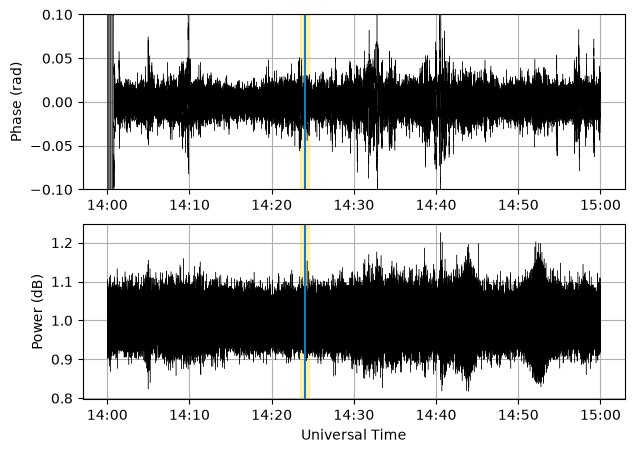

In [18]:
fig = plt.figure(figsize=(7,5))

ax = fig.add_subplot(211)
ax.plot(gnss_time, dt_phs, linewidth=0.3, color='black')
ax.axvspan(xmin=zoom_lims[0], xmax=zoom_lims[1], color='gold', alpha=0.3)
ax.axvline(conjtime)
ax.grid()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_ylim([-0.1,0.1])
ax.set_ylabel('Phase (rad)')

ax = fig.add_subplot(212)
ax.plot(gnss_time, dt_pow, linewidth=0.3, color='black')
ax.axvline(conjtime)
ax.axvspan(xmin=zoom_lims[0], xmax=zoom_lims[1], color='gold', alpha=0.3)
ax.grid()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_ylabel('Power (dB)')
ax.set_xlabel('Universal Time')

## Conjunction Geometry Plots
These are similar to the plots in the `conjunction_list.ipynb` notebook but they use coordinates read from the actual data files instead of predicted position from the conjunction software.  In theory, this makes them more accurate but realistically the difference SHOULD be negligable for the scales we're considering.

The thick portion of the tracks shown represtent the "zoom" time highlighted in yellow in the time series plots.

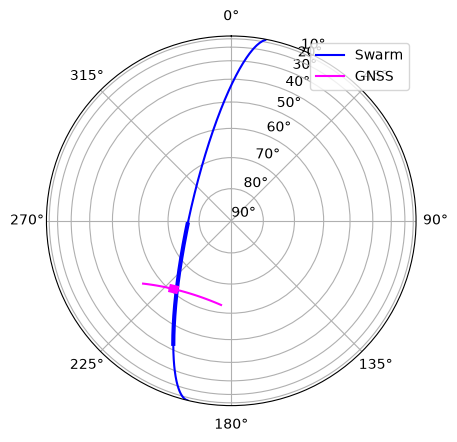

In [27]:
# Calculate sky angle of Swarm   
saz, sel, _ = pm.geodetic2aer(swarm_lat, swarm_lon, swarm_alt, *receiver_site)


# Find start and end indices of zoom section for Swarm
szsi = np.argmin(np.abs(swarm_time-zoom_lims[0]))
szei = np.argmin(np.abs(swarm_time-zoom_lims[1]))+1

# Find start and end indices of zoom section for GNSS
gzsi = np.argmin(np.abs(gnss_pos_time-zoom_lims[0]))
gzei = np.argmin(np.abs(gnss_pos_time-zoom_lims[1]))+1


fig = plt.figure()
ax = fig.add_subplot(111, projection='polar')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
el_ticks = np.arange(90., 0., -10.)
ax.set_ylim(0., 1.)
ax.set_yticks(np.cos(np.deg2rad(el_ticks)))
ax.set_yticklabels([rf'{el}$\degree$' for el in el_ticks.astype(int)])

ax.plot(np.deg2rad(saz), np.cos(np.deg2rad(sel)), color='blue', label='Swarm')
ax.plot(np.deg2rad(saz[szsi:szei]), np.cos(np.deg2rad(sel[szsi:szei])), color='blue', linewidth=3)

ax.plot(np.deg2rad(gaz), np.cos(np.deg2rad(gel)), color='magenta', label='GNSS')
ax.plot(np.deg2rad(gaz[gzsi:gzei]), np.cos(np.deg2rad(gel[gzsi:gzei])), color='magenta', linewidth=6)

ax.legend()

# Some code for plotting a point at every minute of the zoom segment?  Doesn't work...
#ax.scatter(np.deg2rad(swaz[sw_stidx:sw_etidx]), np.cos(np.deg2rad(swel[sw_stidx:sw_etidx])), color='blue')
#ax.scatter(np.deg2rad(interp_swaz), np.cos(np.deg2rad(interp_swel)), color='blue')
#print(swarm_time[sw_stidx:sw_etidx:960])
#for az, el, tm in zip(swaz[sw_stidx:sw_etidx:960], swel[sw_stidx:sw_etidx:960], swarm_time[sw_stidx:sw_etidx:960]):
#    ax.text(np.deg2rad(az), np.cos(np.deg2rad(el)), np.datetime_as_string(tm, unit='m')[11:])
#
#plt.savefig('conj_polar.png')

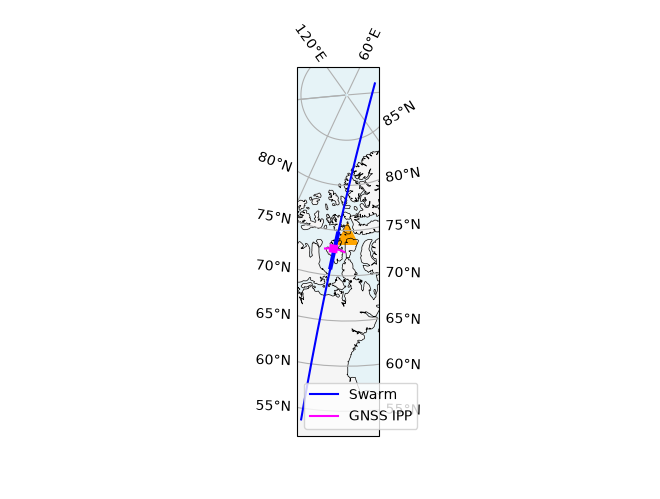

In [28]:
# Calculate GNSS IPPs
ipp_lat, ipp_lon = calc_ipp(receiver_site, [gaz, gel], height=500.)

map_proj = ccrs.AzimuthalEquidistant(central_longitude=receiver_site[1], central_latitude=receiver_site[0])
fig = plt.figure()
ax = fig.add_subplot(111, projection=map_proj)
ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.3)
ax.add_feature(cfeature.LAND, color='whitesmoke')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.gridlines(draw_labels=True)

ax.scatter(receiver_site[1], receiver_site[0], s=200, color='orange', marker='^', transform=ccrs.Geodetic())

ax.plot(swarm_lon, swarm_lat, color='blue', label='Swarm', transform=ccrs.Geodetic())
ax.plot(swarm_lon[szsi:szei], swarm_lat[szsi:szei], color='blue', linewidth=3, transform=ccrs.Geodetic())

ax.plot(ipp_lon, ipp_lat, color='magenta', label='GNSS IPP', transform=ccrs.Geodetic())
ax.plot(ipp_lon[gzsi:gzei], ipp_lat[gzsi:gzei], color='magenta', linewidth=6, transform=ccrs.Geodetic())

ax.legend()

## Combined Analysis
Swarm and GNSS analysis together.

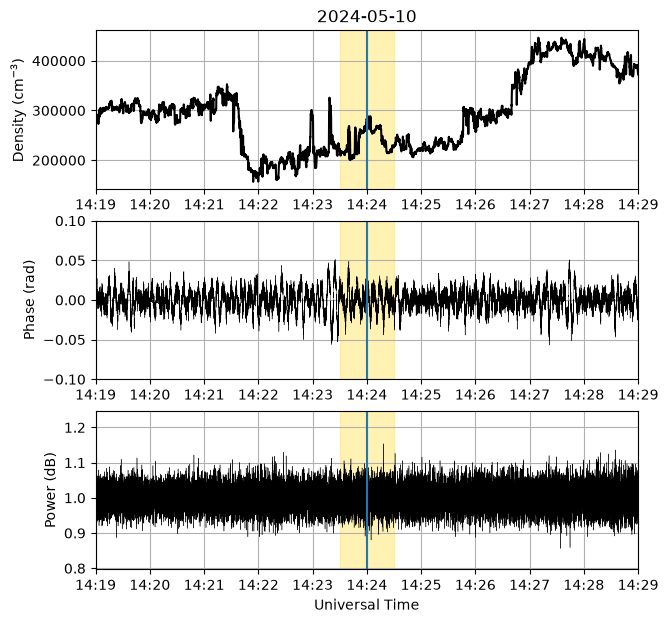

In [29]:
# Three pannel plot aligned for proposal

fig = plt.figure(figsize=(7,7))

ax = fig.add_subplot(311)
ax.plot(swarm_time, dens, color='black')
ax.set_xlim(time_lims)
ax.axvspan(xmin=zoom_lims[0], xmax=zoom_lims[1], color='gold', alpha=0.3)
ax.axvline(conjtime)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.grid()
# ax.set_xlabel('Universal Time')
ax.set_ylabel('Density (cm$^{-3}$)')
ax.set_title(np.datetime_as_string(swarm_time[0], unit='D'))

ax = fig.add_subplot(312)
ax.plot(gnss_time, dt_phs, linewidth=0.3, color='black')
ax.axvspan(xmin=zoom_lims[0], xmax=zoom_lims[1], color='gold', alpha=0.3)
ax.axvline(conjtime)
ax.set_xlim(time_lims)
ax.grid()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_ylim([-0.1,0.1])
ax.set_ylabel('Phase (rad)')

ax = fig.add_subplot(313)
ax.plot(gnss_time, dt_pow, linewidth=0.3, color='black')
ax.axvspan(xmin=zoom_lims[0], xmax=zoom_lims[1], color='gold', alpha=0.3)
ax.axvline(conjtime)
ax.set_xlim(time_lims)
ax.grid()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_ylabel('Power (dB)')
ax.set_xlabel('Universal Time')
plt.savefig('three_panel_exmp.png')


Text(0.5, 0, 'Universal Time')

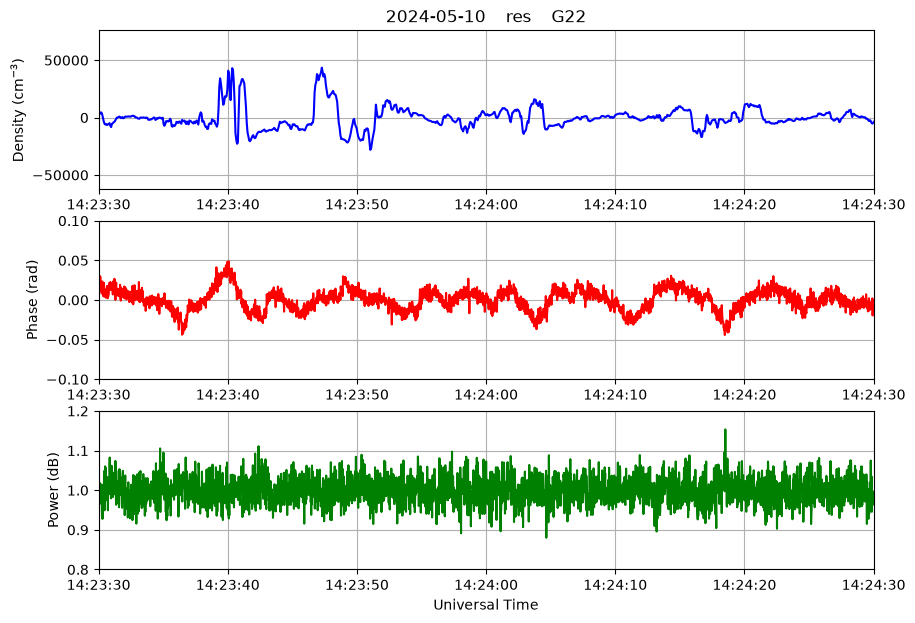

In [33]:
# Detrend Swarm density using the same high pass filter window as used for phase
dt_dens = phase_detrend(dens, datarate=16.)


fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(311)
ax.plot(swarm_time, dt_dens, color='blue')
ax.set_xlim(zoom_lims)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
ax.grid()
#ax.set_ylim([-1.2e4,1.2e4])
ax.set_ylabel(r'Density (cm$^{-3}$)')
ax.set_title(f'{np.datetime_as_string(swarm_time[0], unit='D')}    {receiver_name}    {prn}')

ax = fig.add_subplot(312)
ax.plot(gnss_time, dt_phs, color='red')
ax.set_xlim(zoom_lims)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
ax.grid()
ax.set_ylim([-0.1,0.1])
ax.set_ylabel('Phase (rad)')

ax = fig.add_subplot(313)
ax.plot(gnss_time, dt_pow, color='green')
ax.set_xlim(zoom_lims)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
ax.grid()
ax.set_ylim([0.8,1.2])
ax.set_ylabel('Power (dB)')
ax.set_xlabel('Universal Time')

### Spectra

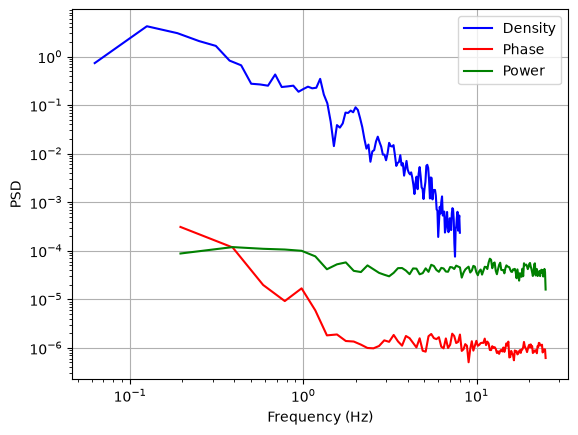

In [41]:
# recalculate the start and end zoom time indices for the actual high rate time series
hzsi = np.argmin(np.abs(gnss_time-zoom_lims[0]))
hzei = np.argmin(np.abs(gnss_time-zoom_lims[1]))+1

# Calculate Welch spectra
f_dens, Pxx_dens = welch(dt_dens[szsi:szei]/10000., fs=16.)
f_phs, Pxx_phs = welch(dt_phs[hzsi:hzei], fs=50.)
f_pow, Pxx_pow = welch(dt_pow[hzsi:hzei], fs=50.)

# Plot
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(f_dens[1:], Pxx_dens[1:], color='blue', label=f'Density')
ax.plot(f_phs[1:], Pxx_phs[1:], color='red', label=f'Phase')
ax.plot(f_pow[1:], Pxx_pow[1:], color='green', label=f'Power')

ax.set_xscale('log')
ax.set_yscale('log')
ax.grid()
ax.legend()
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD')
plt.savefig('spectra_exmp.png')

### Slope Fit

[-2.34318455 -0.86099803]
[-2.53964557 -5.17770878]
[-0.44172063 -4.17530551]


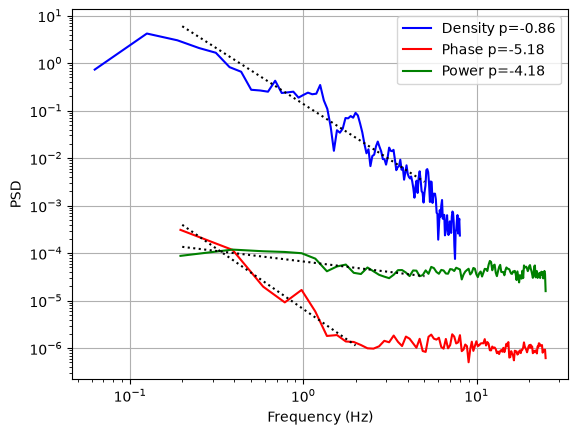

In [40]:
# Line fitting
dens_fl = np.array([0.2, 5.])
lfidx = np.argmin(np.abs(dens_fl[0]-f_dens))
ufidx = np.argmin(np.abs(dens_fl[1]-f_dens))
dens_p = np.polyfit(np.log10(f_dens[lfidx:ufidx]), np.log10(Pxx_dens[lfidx:ufidx]), 1)
print(dens_p)
dens_pl = np.power(10, np.polyval(dens_p, np.log10(dens_fl)))

phs_fl = np.array([0.2, 2.])
lfidx = np.argmin(np.abs(phs_fl[0]-f_phs))
ufidx = np.argmin(np.abs(phs_fl[1]-f_phs))
phs_p = np.polyfit(np.log10(f_phs[lfidx:ufidx]), np.log10(Pxx_phs[lfidx:ufidx]), 1)
print(phs_p)
phs_pl = np.power(10, np.polyval(phs_p, np.log10(phs_fl)))

pow_fl = np.array([0.2, 5.])
lfidx = np.argmin(np.abs(pow_fl[0]-f_pow))
ufidx = np.argmin(np.abs(pow_fl[1]-f_pow))
pow_p = np.polyfit(np.log10(f_pow[lfidx:ufidx]), np.log10(Pxx_pow[lfidx:ufidx]), 1)
print(pow_p)
pow_pl = np.power(10, np.polyval(pow_p, np.log10(pow_fl)))

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(f_dens[1:], Pxx_dens[1:], color='blue', label=f'Density p={dens_p[1]:.2f}')
ax.plot(f_phs[1:], Pxx_phs[1:], color='red', label=f'Phase p={phs_p[1]:.2f}')
ax.plot(f_pow[1:], Pxx_pow[1:], color='green', label=f'Power p={pow_p[1]:.2f}')
ax.plot(dens_fl, dens_pl, linestyle=':', color='black')
ax.plot(phs_fl, phs_pl, linestyle=':', color='black')
ax.plot(pow_fl, pow_pl, linestyle=':', color='black')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid()
ax.legend()
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD')
plt.savefig('spectra_exmp.png')